## Objective
To develop a machine learning model that can identify fraudlent transactions from non-fraudlent transactions using transaction - related data and compare the performance of different classification algorithms

### Importing Libraries

In [1]:
import pandas as pd

### Loading and Overview

In [2]:
data = pd.read_csv("fraud_detection_practice_dataset.csv")

In [3]:
data.shape

(5000, 10)

In [4]:
data.head()

,Transaction_Type,Age,Income,Transaction_Amount,Transactions_24h,Account_Age_Years,Distance_From_Home_Km,Device_Risk_Score,International_Transaction,Is_Fraud
0,ATM,24.0,88703.31,983.54,3.0,4.11,22.48,0.116,Yes,0
1,POS,30.0,113598.86,2368.21,4.0,9.80,77.79,0.042,No,0
2,Transfer,39.0,50010.26,138655.80,6.0,7.77,19.99,0.256,No,0
3,POS,29.0,33763.13,5675.63,7.0,4.40,18.55,0.378,Yes,0
4,Online,33.0,40728.36,5836.97,4.0,5.01,9.21,0.081,No,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_Type           4850 non-null   object 
 1   Age                        4800 non-null   float64
 2   Income                     4750 non-null   float64
 3   Transaction_Amount         4800 non-null   float64
 4   Transactions_24h           4850 non-null   float64
 5   Account_Age_Years          5000 non-null   float64
 6   Distance_From_Home_Km      5000 non-null   float64
 7   Device_Risk_Score          5000 non-null   float64
 8   International_Transaction  4850 non-null   object 
 9   Is_Fraud                   5000 non-null   int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 390.8+ KB


In [6]:
data.describe()

,Age,Income,Transaction_Amount,Transactions_24h,Account_Age_Years,Distance_From_Home_Km,Device_Risk_Score,Is_Fraud
count,4800.000000,4750.000000,4800.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,36.164375,49674.359253,4786.608540,4.023918,4.984134,23.806698,0.247617,0.04820
std,10.589258,23701.723891,9187.237464,2.011476,2.831629,16.818763,0.143199,0.21421
min,18.000000,15000.000000,100.000000,0.000000,0.100000,0.200000,0.004000,0.00000
25%,29.000000,33129.430000,1311.652500,3.000000,2.920000,11.587500,0.137750,0.00000
50%,36.000000,44522.275000,2583.140000,4.000000,4.890000,20.115000,0.225000,0.00000
75%,43.000000,60642.525000,5204.160000,5.000000,6.910000,31.852500,0.336000,0.00000
max,74.000000,250000.000000,147395.760000,13.000000,17.260000,180.150000,0.836000,1.00000


In [7]:
data.columns

Index(['Transaction_Type', 'Age', 'Income', 'Transaction_Amount',
       'Transactions_24h', 'Account_Age_Years', 'Distance_From_Home_Km',
       'Device_Risk_Score', 'International_Transaction', 'Is_Fraud'],
      dtype='object')

### Checking Missing Values and Imputing

In [8]:
data.isnull().sum()

Transaction_Type             150
Age                          200
Income                       250
Transaction_Amount           200
Transactions_24h             150
Account_Age_Years              0
Distance_From_Home_Km          0
Device_Risk_Score              0
International_Transaction    150
Is_Fraud                       0
dtype: int64

In [9]:
num_cols = data.select_dtypes(include = "number").columns.drop("Is_Fraud")
print(num_cols)

Index(['Age', 'Income', 'Transaction_Amount', 'Transactions_24h',
       'Account_Age_Years', 'Distance_From_Home_Km', 'Device_Risk_Score'],
      dtype='object')


In [10]:
for col in num_cols:
    skewness = data[col].skew()

    if -0.5 <= skewness <=0.5:
        data[col] = data[col].fillna(data[col].mean())
        print(col,"Mean")
    else:
        data[col] = data[col].fillna(data[col].median())
        print(col,"Median")


Age Mean
Income Median
Transaction_Amount Median
Transactions_24h Mean
Account_Age_Years Mean
Distance_From_Home_Km Median
Device_Risk_Score Median


In [11]:
data[num_cols].isnull().sum()

Age                      0
Income                   0
Transaction_Amount       0
Transactions_24h         0
Account_Age_Years        0
Distance_From_Home_Km    0
Device_Risk_Score        0
dtype: int64

In [12]:
cat_cols = data.select_dtypes(include = "object").columns
print(cat_cols)

Index(['Transaction_Type', 'International_Transaction'], dtype='object')


In [13]:
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [14]:
data[cat_cols].isnull().sum()

Transaction_Type             0
International_Transaction    0
dtype: int64

In [15]:
data.isnull().sum()

Transaction_Type             0
Age                          0
Income                       0
Transaction_Amount           0
Transactions_24h             0
Account_Age_Years            0
Distance_From_Home_Km        0
Device_Risk_Score            0
International_Transaction    0
Is_Fraud                     0
dtype: int64

### Check Duplicates

In [16]:
data.duplicated().sum()

np.int64(0)

### Detecting Outliers

In [17]:
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower ) | (data[col] > upper)]

    print(col,":",len(outliers),"outliers")

Age : 22 outliers
Income : 240 outliers
Transaction_Amount : 409 outliers
Transactions_24h : 94 outliers
Account_Age_Years : 15 outliers
Distance_From_Home_Km : 159 outliers
Device_Risk_Score : 57 outliers


In [18]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 0.13775
Q3: 0.336
IQR: 0.19825
Lower limit: -0.159625
Upper limit: 0.633375


### Checking Data types

In [19]:
data.dtypes

Transaction_Type              object
Age                          float64
Income                       float64
Transaction_Amount           float64
Transactions_24h             float64
Account_Age_Years            float64
Distance_From_Home_Km        float64
Device_Risk_Score            float64
International_Transaction     object
Is_Fraud                       int64
dtype: object

In [20]:
data.head()

,Transaction_Type,Age,Income,Transaction_Amount,Transactions_24h,Account_Age_Years,Distance_From_Home_Km,Device_Risk_Score,International_Transaction,Is_Fraud
0,ATM,24.0,88703.31,983.54,3.0,4.11,22.48,0.116,Yes,0
1,POS,30.0,113598.86,2368.21,4.0,9.80,77.79,0.042,No,0
2,Transfer,39.0,50010.26,138655.80,6.0,7.77,19.99,0.256,No,0
3,POS,29.0,33763.13,5675.63,7.0,4.40,18.55,0.378,Yes,0
4,Online,33.0,40728.36,5836.97,4.0,5.01,9.21,0.081,No,0


### One-Hot Encoding

In [21]:
data["Transaction_Type"].value_counts()

Transaction_Type
Online      1892
POS         1678
Transfer     730
ATM          700
Name: count, dtype: int64

In [22]:
data = pd.get_dummies(data,columns=["Transaction_Type"],drop_first=True)

In [23]:
data.head()

,Age,Income,Transaction_Amount,Transactions_24h,Account_Age_Years,Distance_From_Home_Km,Device_Risk_Score,International_Transaction,Is_Fraud,Transaction_Type_Online,Transaction_Type_POS,Transaction_Type_Transfer
0,24.0,88703.31,983.54,3.0,4.11,22.48,0.116,Yes,0,False,False,False
1,30.0,113598.86,2368.21,4.0,9.80,77.79,0.042,No,0,False,True,False
2,39.0,50010.26,138655.80,6.0,7.77,19.99,0.256,No,0,False,False,True
3,29.0,33763.13,5675.63,7.0,4.40,18.55,0.378,Yes,0,False,True,False
4,33.0,40728.36,5836.97,4.0,5.01,9.21,0.081,No,0,True,False,False


### Label Encoding

In [24]:
data["International_Transaction"].value_counts()

International_Transaction
No     4153
Yes     847
Name: count, dtype: int64

In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [26]:
data["International_Transaction"] = le.fit_transform(data["International_Transaction"])

In [27]:
data["International_Transaction"].value_counts()

International_Transaction
0    4153
1     847
Name: count, dtype: int64

In [28]:
data.dtypes

Age                          float64
Income                       float64
Transaction_Amount           float64
Transactions_24h             float64
Account_Age_Years            float64
Distance_From_Home_Km        float64
Device_Risk_Score            float64
International_Transaction      int64
Is_Fraud                       int64
Transaction_Type_Online         bool
Transaction_Type_POS            bool
Transaction_Type_Transfer       bool
dtype: object

In [29]:
data.isnull().sum()

Age                          0
Income                       0
Transaction_Amount           0
Transactions_24h             0
Account_Age_Years            0
Distance_From_Home_Km        0
Device_Risk_Score            0
International_Transaction    0
Is_Fraud                     0
Transaction_Type_Online      0
Transaction_Type_POS         0
Transaction_Type_Transfer    0
dtype: int64

### Exploratory Data Analysis

#### Fraud VS Non-Fraud

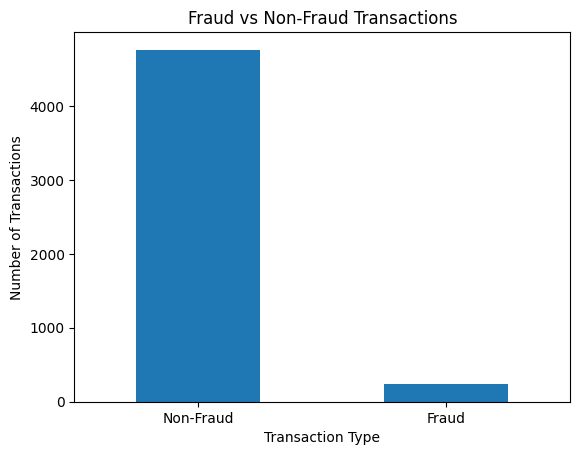

In [96]:
import matplotlib.pyplot as plt

data["Is_Fraud"].value_counts().plot(kind="bar")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Non-Fraud", "Fraud"], rotation=0)
plt.show()

#### Transaction type VS Fraud

### Features and Targets

In [30]:
X = data.drop("Is_Fraud",axis = 1)
Y = data["Is_Fraud"]

In [31]:
print(X.shape)
print(Y.shape)

(5000, 11)
(5000,)


### Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42,stratify = Y)

In [34]:
print(Y.value_counts())

Is_Fraud
0    4759
1     241
Name: count, dtype: int64


### Scaling

For Logistic Regression, SVM and KNN needs "Standard Scaler"

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [36]:
X_train_scaled = scaler.fit_transform(X_train)

In [37]:
X_test_scaled = scaler.fit_transform(X_test)

In [38]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(4000, 11)
(1000, 11)


### Model Building
## Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)

In [40]:
model.fit(X_train_scaled, Y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [41]:
y_pred = model.predict(X_test_scaled)

In [42]:
print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


### Model Evaluation for Logistic Regression Model

In [43]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

accuracy = accuracy_score(Y_test,y_pred)
precision = precision_score(Y_test,y_pred)
recall = recall_score(Y_test,y_pred)
f1 = f1_score(Y_test,y_pred)

print("Accuracy : ",accuracy)
print("Precision : ",precision)
print("Recall Score : ",recall)
print("F1 score : ",f1)

Accuracy :  0.952
Precision :  0.0
Recall Score :  0.0
F1 score :  0.0


c:\Users\star\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [44]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[952   0]
 [ 48   0]]



The model achieved 95.2% accuracy, but it failed to detect any fraudlent transactions. Therefore, accuracy alone is not sufficient for evaluating this fraud detection model

In [45]:
print(Y_train.value_counts())

Is_Fraud
0    3807
1     193
Name: count, dtype: int64


#### **Observation**
The dataset is imbalanced, with 3,807 non-fraud transactions and only 193 fraud transactions. Due to this imbalance, the Logistic Regression model predicted all test transactions as non-fraud, resulting in hig accuracy but 0 % recall for fraud detection. 

## Decision Tree

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
dt_model = DecisionTreeClassifier(random_state = 42)

In [48]:
dt_model.fit(X_train,Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [49]:
y_pred_dt = dt_model.predict(X_test)

In [50]:
print(y_pred_dt[:10])

[0 0 0 0 0 0 0 0 0 0]


### Model Evaluation for Decision Tree

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(Y_test, y_pred_dt))
print("Precision:", precision_score(Y_test, y_pred_dt, zero_division=0))
print("Recall   :", recall_score(Y_test, y_pred_dt, zero_division=0))
print("F1 Score :", f1_score(Y_test, y_pred_dt, zero_division=0))

Accuracy : 0.912
Precision: 0.045454545454545456
Recall   : 0.041666666666666664
F1 Score : 0.043478260869565216


In [52]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred_dt)
print(cm)

[[910  42]
 [ 46   2]]


#### **Observation**
The Decision Tree model achieved 91.2% accuracy, but its fraud detection performance was poor, with only 4.17% recall and 4.35% F1-score. Out of 48 actual fraud transactions, the model detected only 2, while 46 were misclassified as non-fraud. This indicates that the class imbalance significantly affected the model's ability to detect fraud.

## Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
rf_model = RandomForestClassifier(n_estimators = 100,random_state = 42)

In [55]:
rf_model.fit(X_train,Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [56]:
y_pred_rf = rf_model.predict(X_test)

In [57]:
print(y_pred_rf[:10])

[0 0 0 0 0 0 0 0 0 0]


### Model Evaluation for Random Forest

In [58]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("Accuracy : ",accuracy_score(Y_test,y_pred_rf))
print("Precision : ",precision_score(Y_test,y_pred_rf))
print("Recall : ",recall_score(Y_test,y_pred_rf))
print("F1 score : ",f1_score(Y_test,y_pred_rf))

Accuracy :  0.952
Precision :  0.0
Recall :  0.0
F1 score :  0.0


c:\Users\star\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [60]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(Y_test, y_pred_rf)
print(cm_rf)

[[952   0]
 [ 48   0]]


### **Observation**
The Random Forest model achieved 95.2% accuracy, but it failed to detect any fraudlent transactions, resulting in 0% precision, recall, and F1-score for the fraud class. All 48 actual fraud transactions were misclassified as non-fraud, showing that the class imbalance strongly affected the model's fraud detection performance.

## KNN - (K-Nearest Neighbors)

In [61]:
from sklearn.neighbors import KNeighborsClassifier

In [62]:
knn_model = KNeighborsClassifier(n_neighbors = 5)

In [64]:
knn_model.fit(X_train_scaled,Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [65]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [66]:
print(y_pred_knn[:10])

[0 0 0 0 0 0 0 0 0 0]


### Model Evaluation for KNN

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(Y_test, y_pred_knn))
print("Precision:", precision_score(Y_test, y_pred_knn, zero_division=0))
print("Recall   :", recall_score(Y_test, y_pred_knn, zero_division=0))
print("F1 Score :", f1_score(Y_test, y_pred_knn, zero_division=0))

Accuracy : 0.951
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [70]:
from sklearn.metrics import confusion_matrix
cm_knn = confusion_matrix(Y_test, y_pred_knn)

In [71]:
print(cm_knn)

[[951   1]
 [ 48   0]]


### **Observation**
The KNN model achieved 95.1% accuracy, but it failed to detect any fraudulent transactions, resulting in 0% precision, recall, and F1-score for the fraud class. All 48 actual fraud transactions were classified as non-fraud, indicating that the class imbalance significantly affected the model's ability to detect fraud.

## SVM - (Support Vector Machine)

In [72]:
from sklearn.svm import SVC

In [73]:
svm_model = SVC()

In [74]:
svm_model.fit(X_train_scaled,Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [75]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [76]:
print(y_pred_svm[:15])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Model Evaluation for SVM

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(Y_test, y_pred_svm))
print("Precision:", precision_score(Y_test, y_pred_svm, zero_division=0))
print("Recall   :", recall_score(Y_test, y_pred_svm, zero_division=0))
print("F1 Score :", f1_score(Y_test, y_pred_svm, zero_division=0))

Accuracy : 0.952
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [80]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(Y_test, y_pred_svm)
print(cm_svm)

[[952   0]
 [ 48   0]]


## **Observation**
The SVM model achieved 95.2% accuracy, but it failed to detect any fraudulent transactions, resulting in 0% precision, recall, and F1-score for the fraud class. All 48 actual fraud transactions were classified as non-fraud, indicating that the class imbalance significantly affected the model's fraud detection performance.

## XG Boost

In [85]:
from xgboost import XGBClassifier

In [86]:
xgb_model = XGBClassifier(n_estimators=100,random_state=42)

In [88]:
xgb_model.fit(X_train, Y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [89]:
y_pred_xgb = xgb_model.predict(X_test)

In [90]:
print(y_pred_xgb[:15])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Model Evaluation for XG Boost

In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(Y_test, y_pred_xgb))
print("Precision:", precision_score(Y_test, y_pred_xgb, zero_division=0))
print("Recall   :", recall_score(Y_test, y_pred_xgb, zero_division=0))
print("F1 Score :", f1_score(Y_test, y_pred_xgb, zero_division=0))

Accuracy : 0.948
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [94]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(Y_test, y_pred_xgb)
print(cm_xgb)

[[948   4]
 [ 48   0]]


### **Observation**
The XGBoost model achieved 94.8% accuracy, but it failed to detect any fraudulent transactions, resulting in 0% precision, recall, and F1-score for the fraud class. All 48 actual fraud transactions were classified as non-fraud, indicating that the class imbalance significantly affected the model's ability to detect fraud.

### OverAll Model Results

| Model               | Accuracy | Precision | Recall | F1 Score |
| ------------------- | -------: | --------: | -----: | -------: |
| Logistic Regression |    95.2% |        0% |     0% |       0% |
| Decision Tree       |    91.2% |     4.55% |  4.17% |    4.35% |
| Random Forest       |    95.2% |        0% |     0% |       0% |
| KNN                 |    95.1% |        0% |     0% |       0% |
| SVM                 |    95.2% |        0% |     0% |       0% |
| XGBoost             |    94.8% |        0% |     0% |       0% |


## Conclusion
The six classification models were trained and evaluated for fraud detection. Although most models achieved high accuracy, their precision, recall, and F1-scores for the fraud class were very low. This shows that accuracy alone is not a suitable metric for an imbalanced fraud detection dataset. The models struggled to identify fraudulent transactions, highlighting the importance of using appropriate evaluation metrics and class-imbalance handling techniques in fraud detection problems.